In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline  
from warnings import filterwarnings

In [27]:
from sklearn.datasets import load_iris
data=load_iris()

In [28]:
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [29]:
data.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [30]:
data.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [31]:
df=load_iris(as_frame=True).frame
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


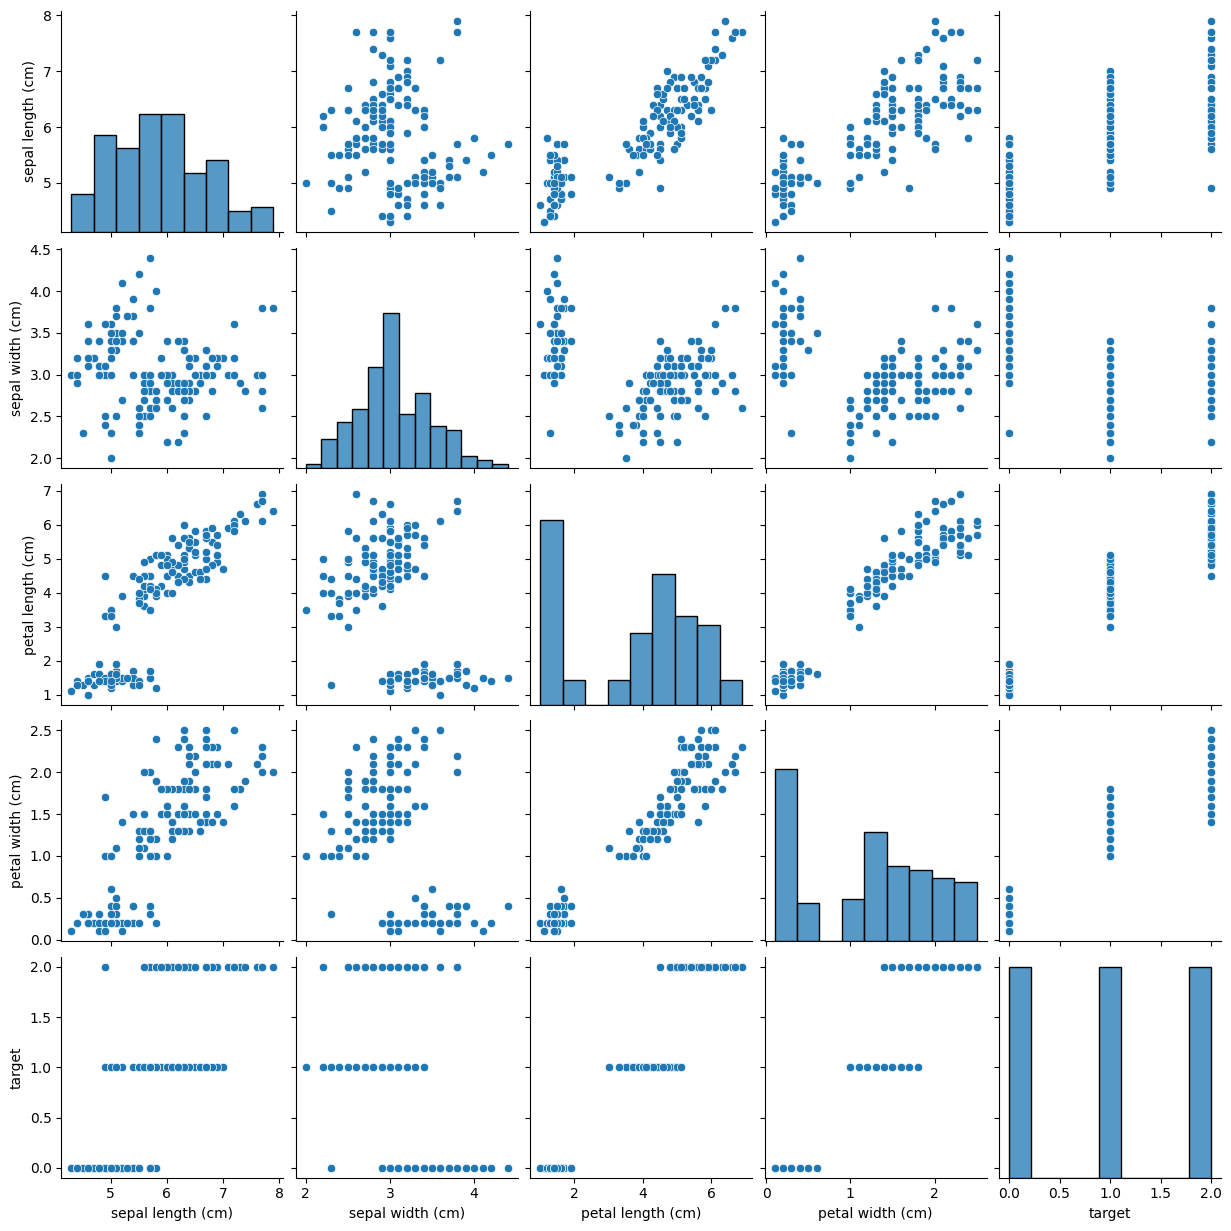

In [32]:
sns.pairplot(data=df)

<Axes: xlabel='sepal length (cm)', ylabel='petal width (cm)'>

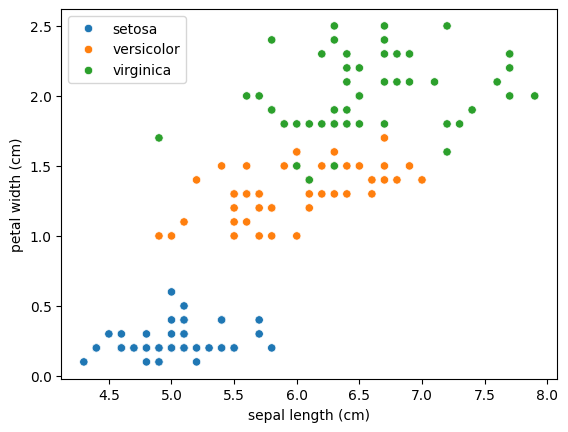

In [33]:
sns.scatterplot(x='sepal length (cm)', y='petal width (cm)', hue=data.target_names[data.target], data=df)

In [34]:
X = data.data   #independent variables
y = data.target  #dependent varaible

In [35]:
print(data.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [36]:
X = pd.DataFrame(data.data , columns=data.feature_names)
X


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [37]:
y = pd.Series(data.target, name='target')
y

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 150, dtype: int64

<Axes: >

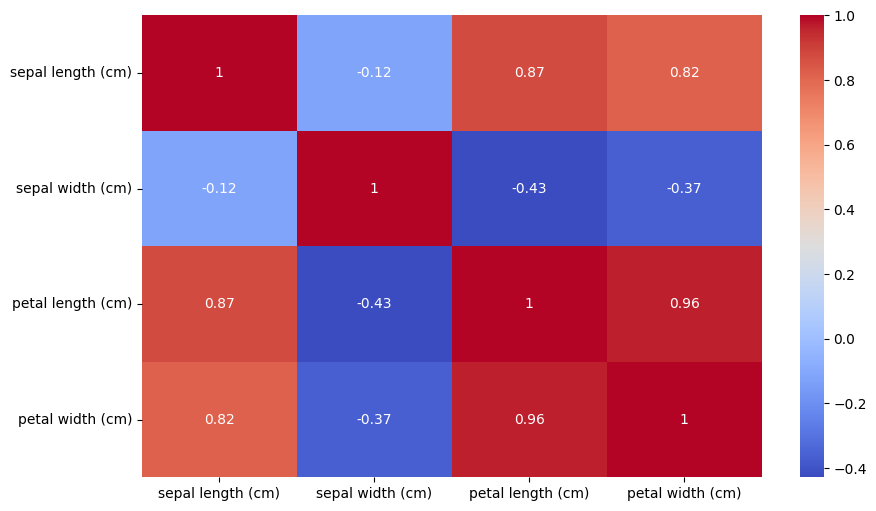

In [38]:
plt.figure(figsize=(10,6))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm')

<Axes: xlabel='sepal length (cm)', ylabel='sepal width (cm)'>

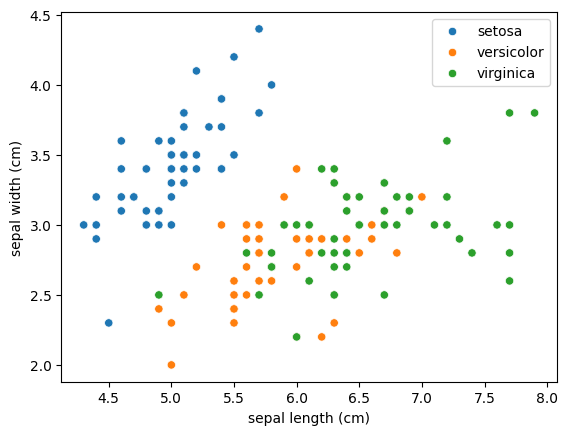

In [39]:
sns.scatterplot(x='sepal length (cm)', y='sepal width (cm)', hue=data.target_names[data.target], data=X)

In [40]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [41]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((120, 4), (30, 4), (120,), (30,))

<Axes: xlabel='sepal length (cm)', ylabel='sepal width (cm)'>

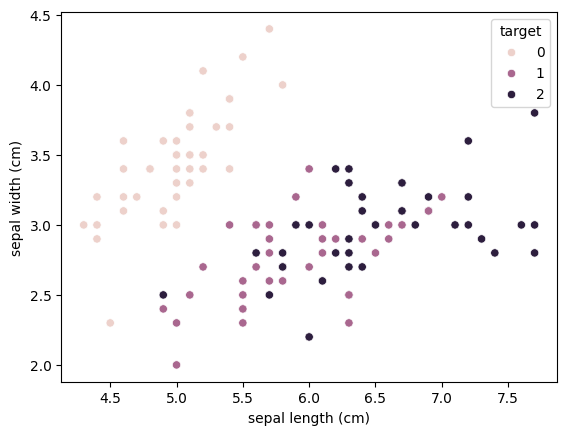

In [42]:
sns.scatterplot(x=X_train.iloc[:,0], y=X_train.iloc[:,1], hue=y_train)


In [43]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC())
])

param_grid = {
    'svc__C': [0.1, 1, 10, 100],
    'svc__gamma': [1, 0.1, 0.01],
    'svc__kernel': ['linear', 'rbf']
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)
grid.predict(X_test)

print(f"Best Accuracy: {grid.best_score_:.4f}")
print(f"Best Params: {grid.best_params_}")

Best Accuracy: 0.9667
Best Params: {'svc__C': 100, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}


In [44]:
new_flower = np.array([[5.1, 1.9, 1.4, 0.2]])

prediction = grid.predict(new_flower)

print(data.target_names[prediction])


['setosa']


C:\Users\burha\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [45]:
new_flower = [[6.1, 2.8, 4.7, 1.2]]
prediction=grid.predict(new_flower)

data.target_names[prediction[0]]


C:\Users\burha\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


np.str_('versicolor')

In [46]:
from sklearn.metrics import classification_report,r2_score

y_pred = grid.predict(X_test)

# Show the results
print(classification_report(y_test, y_pred, target_names=data.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.89      0.94         9
   virginica       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



In [47]:
results = pd.DataFrame(grid.cv_results_)

print(results[['params', 'mean_test_score', 'rank_test_score']].sort_values('rank_test_score'))

                                               params  mean_test_score  \
23  {'svc__C': 100, 'svc__gamma': 0.01, 'svc__kern...         0.966667   
0   {'svc__C': 0.1, 'svc__gamma': 1, 'svc__kernel'...         0.958333   
4   {'svc__C': 0.1, 'svc__gamma': 0.01, 'svc__kern...         0.958333   
2   {'svc__C': 0.1, 'svc__gamma': 0.1, 'svc__kerne...         0.958333   
12  {'svc__C': 10, 'svc__gamma': 1, 'svc__kernel':...         0.958333   
14  {'svc__C': 10, 'svc__gamma': 0.1, 'svc__kernel...         0.958333   
16  {'svc__C': 10, 'svc__gamma': 0.01, 'svc__kerne...         0.958333   
8   {'svc__C': 1, 'svc__gamma': 0.1, 'svc__kernel'...         0.950000   
15  {'svc__C': 10, 'svc__gamma': 0.1, 'svc__kernel...         0.950000   
10  {'svc__C': 1, 'svc__gamma': 0.01, 'svc__kernel...         0.950000   
20  {'svc__C': 100, 'svc__gamma': 0.1, 'svc__kerne...         0.950000   
21  {'svc__C': 100, 'svc__gamma': 0.1, 'svc__kerne...         0.950000   
17  {'svc__C': 10, 'svc__gamma': 0.01,

In [48]:
new_flower = np.array([[6.1, 3.0, 5.4, 2.2]])  

prediction = grid.predict(new_flower)

print(data.target_names[prediction])


['virginica']


C:\Users\burha\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


SVM focuses on maximizing the margin between classes rather than directly
optimizing classification probability. This makes it effective in
high-dimensional spaces but sensitive to feature scaling.
